In [8]:
!pip install -q open_clip_torch timm

import os
import random
from pathlib import Path
from typing import List, Tuple

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from collections import defaultdict

import open_clip

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("GPU count:", torch.cuda.device_count())

Device: cuda
GPU count: 2


In [9]:
DATA_ROOT = Path("/kaggle/input/sign-language-gesture-images-dataset")

print("Top-level contents:")
for p in DATA_ROOT.iterdir():
    print(" ", p)

def find_image_root(root: Path) -> Path:
    candidates = []
    for dirpath, dirnames, filenames in os.walk(root):
        dirpath = Path(dirpath)
        if len(dirnames) > 0:
            candidates.append(dirpath)
    if not candidates:
        return root
    candidates = sorted(candidates, key=lambda p: len(str(p)))
    return candidates[-1]

IMAGE_ROOT = find_image_root(DATA_ROOT)
print("\nAssumed IMAGE_ROOT:", IMAGE_ROOT)

print("\nClass folders under IMAGE_ROOT:")
class_dirs = sorted([d for d in IMAGE_ROOT.iterdir() if d.is_dir()])
for d in class_dirs:
    print(" ", d.name)

class SignLanguageDataset(Dataset):
    def __init__(self, root: Path, preprocess, max_per_class: int = None):
       
        self.root = Path(root)
        self.preprocess = preprocess

        self.classes = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.samples: List[Tuple[str, int]] = []
        for cls in self.classes:
            folder = self.root / cls
            imgs = [p for p in folder.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]]
            imgs = sorted(imgs)
            if max_per_class is not None:
                imgs = imgs[:max_per_class]
            for img_path in imgs:
                self.samples.append((str(img_path), self.class_to_idx[cls]))

        print(f"Found {len(self.samples)} images across {len(self.classes)} classes.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img = self.preprocess(img)
        return img, label

print("\nLoading CLIP model...")
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)
tokenizer = open_clip.get_tokenizer("ViT-B-32")

model.eval()
model.to(device)

if torch.cuda.device_count() > 1:
    print("Using DataParallel over", torch.cuda.device_count(), "GPUs")
    model = nn.DataParallel(model)


MAX_PER_CLASS = None  

full_dataset = SignLanguageDataset(IMAGE_ROOT, preprocess, max_per_class=MAX_PER_CLASS)

train_ratio, val_ratio = 0.8, 0.1
total_len = len(full_dataset)
train_len = int(total_len * train_ratio)
val_len   = int(total_len * val_ratio)
test_len  = total_len - train_len - val_len

train_ds, val_ds, test_ds = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(SEED)
)

print(f"\nDataset sizes -> Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


def build_prompts_for_class(class_name: str):

    raw = class_name.strip()

    if raw == "_":
        concept = "space"
    else:
        concept = raw

    prompts = []

    if len(raw) == 1 and raw.isalpha():
        letter = raw.upper()
        prompts.extend([
            f"a high-contrast black and white image of a single hand showing the American Sign Language alphabet letter '{letter}' on a black background",
            f"a grayscale image of a right hand making the sign for the letter '{letter}' in American Sign Language, centered on a dark background",
            f"a simple black background with a white hand gesture representing the ASL letter '{letter}'",
            f"a clear image of a static hand pose for the American Sign Language letter '{letter}'",
        ])
    elif raw.isdigit():
        # Digit
        digit = raw
        prompts.extend([
            f"a high-contrast black and white image of a single hand showing the American Sign Language digit '{digit}' on a black background",
            f"a grayscale image of a right hand making the sign for the number '{digit}' in sign language, centered on a dark background",
            f"a simple black background with a white hand gesture representing the sign language digit '{digit}'",
            f"a clear image of a static hand pose for the sign language number '{digit}'",
        ])
    elif raw == "_":
        # Space sign
        prompts.extend([
            "a high-contrast black and white image of a single hand showing the American Sign Language sign for space between words on a black background",
            "a grayscale image of a right hand making the ASL gesture meaning space or blank, centered on a dark background",
            "a simple black background with a white hand gesture representing the sign language symbol for space",
            "a clear image of a static hand pose that means space in sign language",
        ])
    else:
        prompts.extend([
            f"a high-contrast black and white image of a single hand showing the sign language gesture for '{concept}' on a black background",
            f"a grayscale image of a right hand making the sign language gesture for '{concept}', centered on a dark background",
        ])

    return prompts

classes = full_dataset.classes
print("\nClasses (folder names):")
for c in classes:
    print(" ", c)

print("\nExample prompt set for class 'A' (if exists):")
if "A" in classes:
    for p in build_prompts_for_class("A"):
        print("  -", p)

print("\nEncoding text prompts with ensembling...")

all_text_features = []

with torch.no_grad():
    for cls in classes:
        prompts = build_prompts_for_class(cls)
        tokens = tokenizer(prompts).to(device)

        if isinstance(model, nn.DataParallel):
            feats = model.module.encode_text(tokens)
        else:
            feats = model.encode_text(tokens)

        feats = feats / feats.norm(dim=-1, keepdim=True)
        cls_feat = feats.mean(dim=0)
        cls_feat = cls_feat / cls_feat.norm(dim=-1, keepdim=True)

        all_text_features.append(cls_feat.unsqueeze(0))

    text_features = torch.cat(all_text_features, dim=0) 

print("Ensembled text feature shape:", text_features.shape)

@torch.no_grad()
def evaluate_zero_shot(dataloader, split_name="Test"):
    model.eval()
    total = 0
    correct = 0

    per_class_total = defaultdict(int)
    per_class_correct = defaultdict(int)

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        if isinstance(model, nn.DataParallel):
            image_features = model.module.encode_image(images)
        else:
            image_features = model.encode_image(images)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = image_features @ text_features.T  

        preds = logits.argmax(dim=-1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        for y, yhat in zip(labels.tolist(), preds.tolist()):
            per_class_total[y] += 1
            if y == yhat:
                per_class_correct[y] += 1

    overall_acc = correct / total if total > 0 else 0.0
    print(f"\n[{split_name}] Zero-shot accuracy: {overall_acc*100:.2f}%  ({correct}/{total})")

    print(f"\n[{split_name}] Per-class accuracy:")
    for idx, cls_name in enumerate(classes):
        if per_class_total[idx] == 0:
            acc = 0.0
        else:
            acc = per_class_correct[idx] / per_class_total[idx]
        print(f"  {cls_name:10s} -> {acc*100:5.1f}%  ({per_class_correct[idx]}/{per_class_total[idx]})")

    return overall_acc


_ = evaluate_zero_shot(test_loader, split_name="Test")

_ = evaluate_zero_shot(val_loader, split_name="Val")

Top-level contents:
  /kaggle/input/sign-language-gesture-images-dataset/Gesture Image Pre-Processed Data
  /kaggle/input/sign-language-gesture-images-dataset/Gesture Image Data

Assumed IMAGE_ROOT: /kaggle/input/sign-language-gesture-images-dataset/Gesture Image Pre-Processed Data

Class folders under IMAGE_ROOT:
  0
  1
  2
  3
  4
  5
  6
  7
  8
  9
  A
  B
  C
  D
  E
  F
  G
  H
  I
  J
  K
  L
  M
  N
  O
  P
  Q
  R
  S
  T
  U
  V
  W
  X
  Y
  Z
  _

Loading CLIP model...
Using DataParallel over 2 GPUs
Found 55500 images across 37 classes.

Dataset sizes -> Train: 44400, Val: 5550, Test: 5550

Classes (folder names):
  0
  1
  2
  3
  4
  5
  6
  7
  8
  9
  A
  B
  C
  D
  E
  F
  G
  H
  I
  J
  K
  L
  M
  N
  O
  P
  Q
  R
  S
  T
  U
  V
  W
  X
  Y
  Z
  _

Example prompt set for class 'A' (if exists):
  - a high-contrast black and white image of a single hand showing the American Sign Language alphabet letter 'A' on a black background
  - a grayscale image of a right h

In [10]:
EMBED_DIM = text_features.shape[1] 
NUM_CLASSES = len(classes)

if isinstance(model, nn.DataParallel):
    clip_backbone = model.module
else:
    clip_backbone = model

for p in clip_backbone.parameters():
    p.requires_grad = False

class ClipImageClassifier(nn.Module):
    def __init__(self, clip_model, embed_dim, num_classes):
        super().__init__()
        self.clip_model = clip_model
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            feats = self.clip_model.encode_image(x)  
        feats = feats / feats.norm(dim=-1, keepdim=True)
        feats = feats.detach()
        logits = self.fc(feats)
        return logits

classifier = ClipImageClassifier(clip_backbone, EMBED_DIM, NUM_CLASSES).to(device)

if torch.cuda.device_count() > 1:
    print("Using DataParallel for classifier over", torch.cuda.device_count(), "GPUs")
    classifier = nn.DataParallel(classifier)

if isinstance(classifier, nn.DataParallel):
    head_params = classifier.module.fc.parameters()
else:
    head_params = classifier.fc.parameters()

optimizer = torch.optim.AdamW(head_params, lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

def train_one_epoch(cls_model, loader, optimizer, scaler, epoch):
    cls_model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Train Epoch {epoch}", leave=False)
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = cls_model(images)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = logits.argmax(dim=1)
        correct = (preds == labels).sum().item()

        batch_size = labels.size(0)
        total += batch_size
        running_correct += correct
        running_loss += loss.item() * batch_size

        pbar.set_postfix({
            "loss": f"{running_loss / total:.4f}",
            "acc": f"{100.0 * running_correct / total:.2f}%"
        })

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def eval_classifier(cls_model, loader, split_name="Val"):
    cls_model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = cls_model(images)
            loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)
        correct = (preds == labels).sum().item()

        batch_size = labels.size(0)
        total += batch_size
        running_correct += correct
        running_loss += loss.item() * batch_size

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    print(f"[{split_name}] Loss: {epoch_loss:.4f} | Acc: {epoch_acc*100:.2f}% ({running_correct}/{total})")
    return epoch_loss, epoch_acc

EPOCHS = 10             
best_val_acc = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(classifier, train_loader, optimizer, scaler, epoch)
    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Train Acc={train_acc*100:.2f}%")

    val_loss, val_acc = eval_classifier(classifier, val_loader, split_name="Val")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        if isinstance(classifier, nn.DataParallel):
            best_state = classifier.module.state_dict()
        else:
            best_state = classifier.state_dict()
        print(f"  -> New best val acc: {best_val_acc*100:.2f}% (saving state)")

if best_state is not None:
    if isinstance(classifier, nn.DataParallel):
        classifier.module.load_state_dict(best_state)
    else:
        classifier.load_state_dict(best_state)

print("\nFinal evaluation on TEST set with best model:")
_ = eval_classifier(classifier, test_loader, split_name="Test")

Using DataParallel for classifier over 2 GPUs


/tmp/ipykernel_47/92850760.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))


Train Epoch 1:   0%|          | 0/347 [00:00<?, ?it/s]

/tmp/ipykernel_47/92850760.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


Epoch 1: Train Loss=3.1350, Train Acc=74.14%


...

Epoch 8: Train Loss=0.5818, Train Acc=96.34%
[Val] Loss: 0.5333 | Acc: 96.97% (5382/5550)
  -> New best val acc: 96.97% (saving state)


Train Epoch 9:   0%|          | 0/347 [00:00<?, ?it/s]

Epoch 9: Train Loss=0.4975, Train Acc=96.65%
[Val] Loss: 0.4588 | Acc: 97.12% (5390/5550)
  -> New best val acc: 97.12% (saving state)


Train Epoch 10:   0%|          | 0/347 [00:00<?, ?it/s]

Epoch 10: Train Loss=0.4311, Train Acc=96.90%
[Val] Loss: 0.3996 | Acc: 97.21% (5395/5550)
  -> New best val acc: 97.21% (saving state)

Final evaluation on TEST set with best model:
[Test] Loss: 0.3996 | Acc: 96.88% (5377/5550)


In [11]:
@torch.no_grad()
def eval_classifier_detailed(cls_model, loader, classes, split_name="Test"):
    cls_model.eval()
    total = 0
    correct = 0

    per_class_total = defaultdict(int)
    per_class_correct = defaultdict(int)

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            logits = cls_model(images)

        preds = logits.argmax(dim=1)

        batch_size = labels.size(0)
        total += batch_size
        correct += (preds == labels).sum().item()

        for y, yhat in zip(labels.tolist(), preds.tolist()):
            per_class_total[y] += 1
            if y == yhat:
                per_class_correct[y] += 1

    overall_acc = correct / total if total > 0 else 0.0
    print(f"\n[{split_name}] Accuracy: {overall_acc*100:.2f}%  ({correct}/{total})")

    print(f"\n[{split_name}] Per-class accuracy:")
    for idx, cls_name in enumerate(classes):
        if per_class_total[idx] == 0:
            acc = 0.0
        else:
            acc = per_class_correct[idx] / per_class_total[idx]
        print(f"  {cls_name:10s} -> {acc*100:5.1f}%  ({per_class_correct[idx]}/{per_class_total[idx]})")

    return overall_acc

if best_state is not None:
    if isinstance(classifier, nn.DataParallel):
        classifier.module.load_state_dict(best_state)
    else:
        classifier.load_state_dict(best_state)

_ = eval_classifier_detailed(classifier, test_loader, classes, split_name="Test")

/tmp/ipykernel_47/3578060018.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):



[Test] Accuracy: 96.88%  (5377/5550)

[Test] Per-class accuracy:
  0          -> 100.0%  (133/133)
  1          -> 100.0%  (135/135)
  2          ->  97.7%  (127/130)
  3          ->  97.2%  (138/142)
  4          ->  90.6%  (115/127)
  5          ->  95.1%  (135/142)
  6          ->  97.2%  (140/144)
  7          ->  97.9%  (142/145)
  8          -> 100.0%  (150/150)
  9          ->  98.9%  (176/178)
  A          ->  99.3%  (143/144)
  B          -> 100.0%  (172/172)
  C          -> 100.0%  (126/126)
  D          ->  90.2%  (129/143)
  E          ->  99.3%  (144/145)
  F          ->  84.5%  (131/155)
  G          ->  83.9%  (120/143)
  H          ->  89.4%  (144/161)
  I          ->  97.6%  (166/170)
  J          ->  99.3%  (140/141)
  K          ->  94.9%  (149/157)
  L          ->  99.4%  (167/168)
  M          ->  95.8%  (137/143)
  N          ->  98.6%  (145/147)
  O          -> 100.0%  (141/141)
  P          ->  94.8%  (146/154)
  Q          -> 100.0%  (148/148)
  R          -> 


Showing a few prediction examples from the TEST set (TRAINED CLASSIFIER)...


/tmp/ipykernel_47/1630614807.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


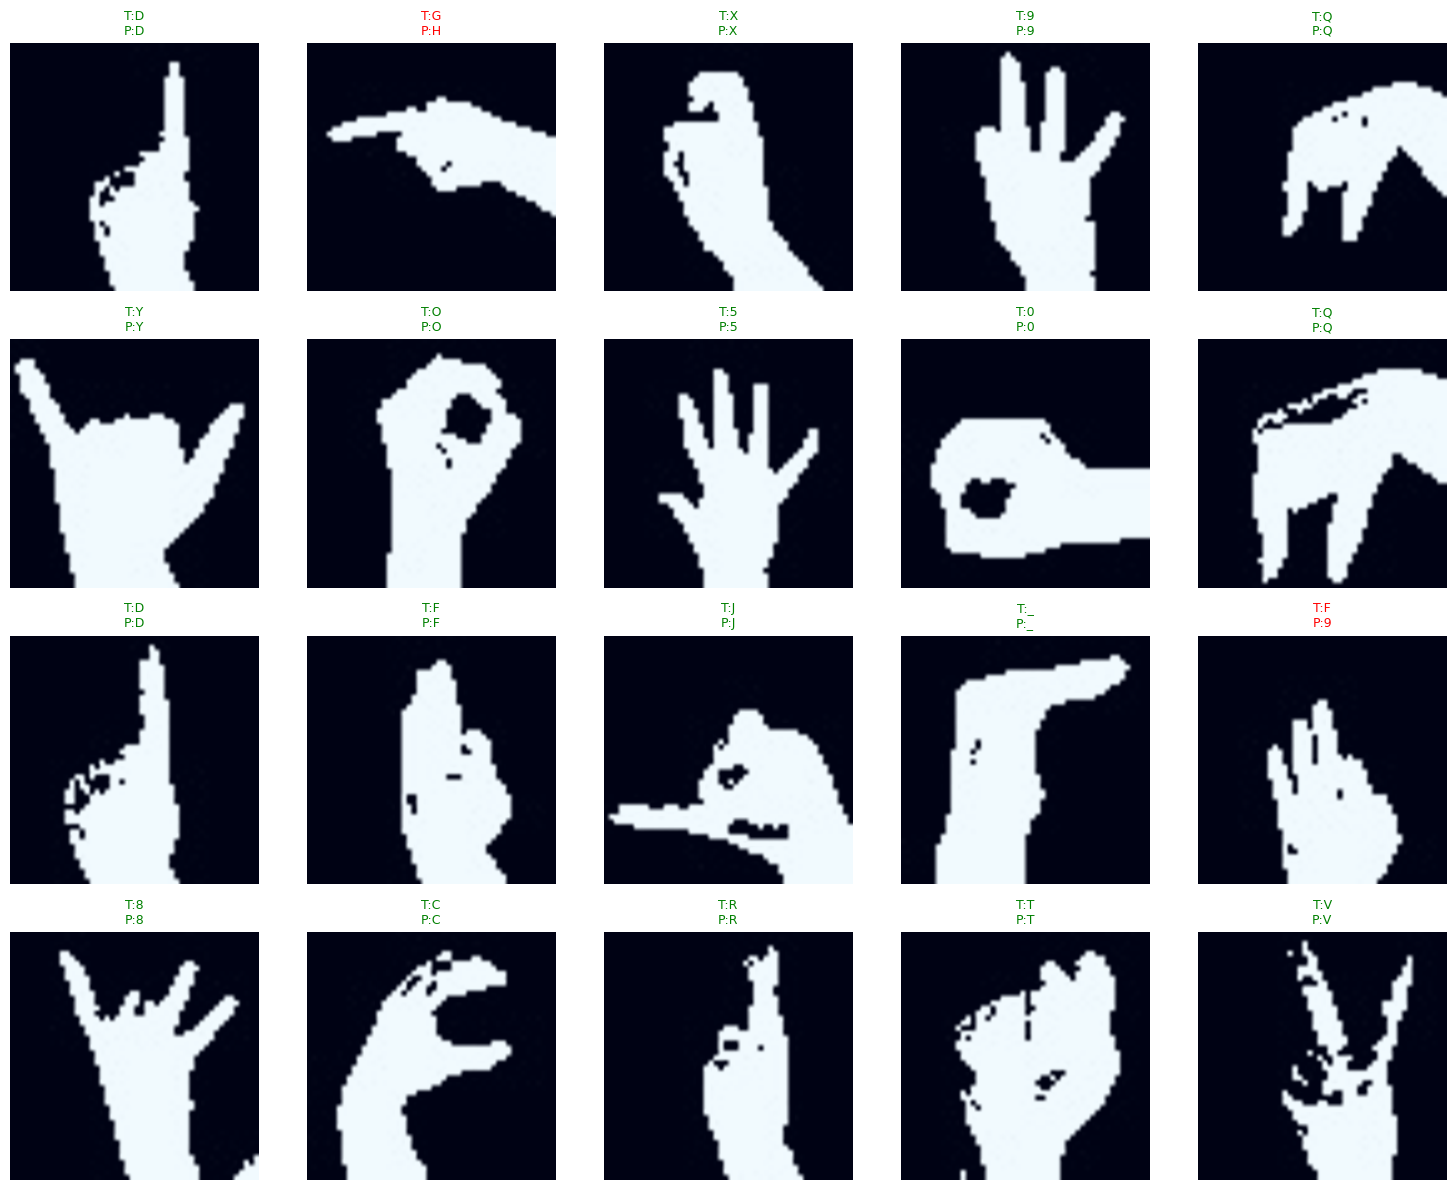

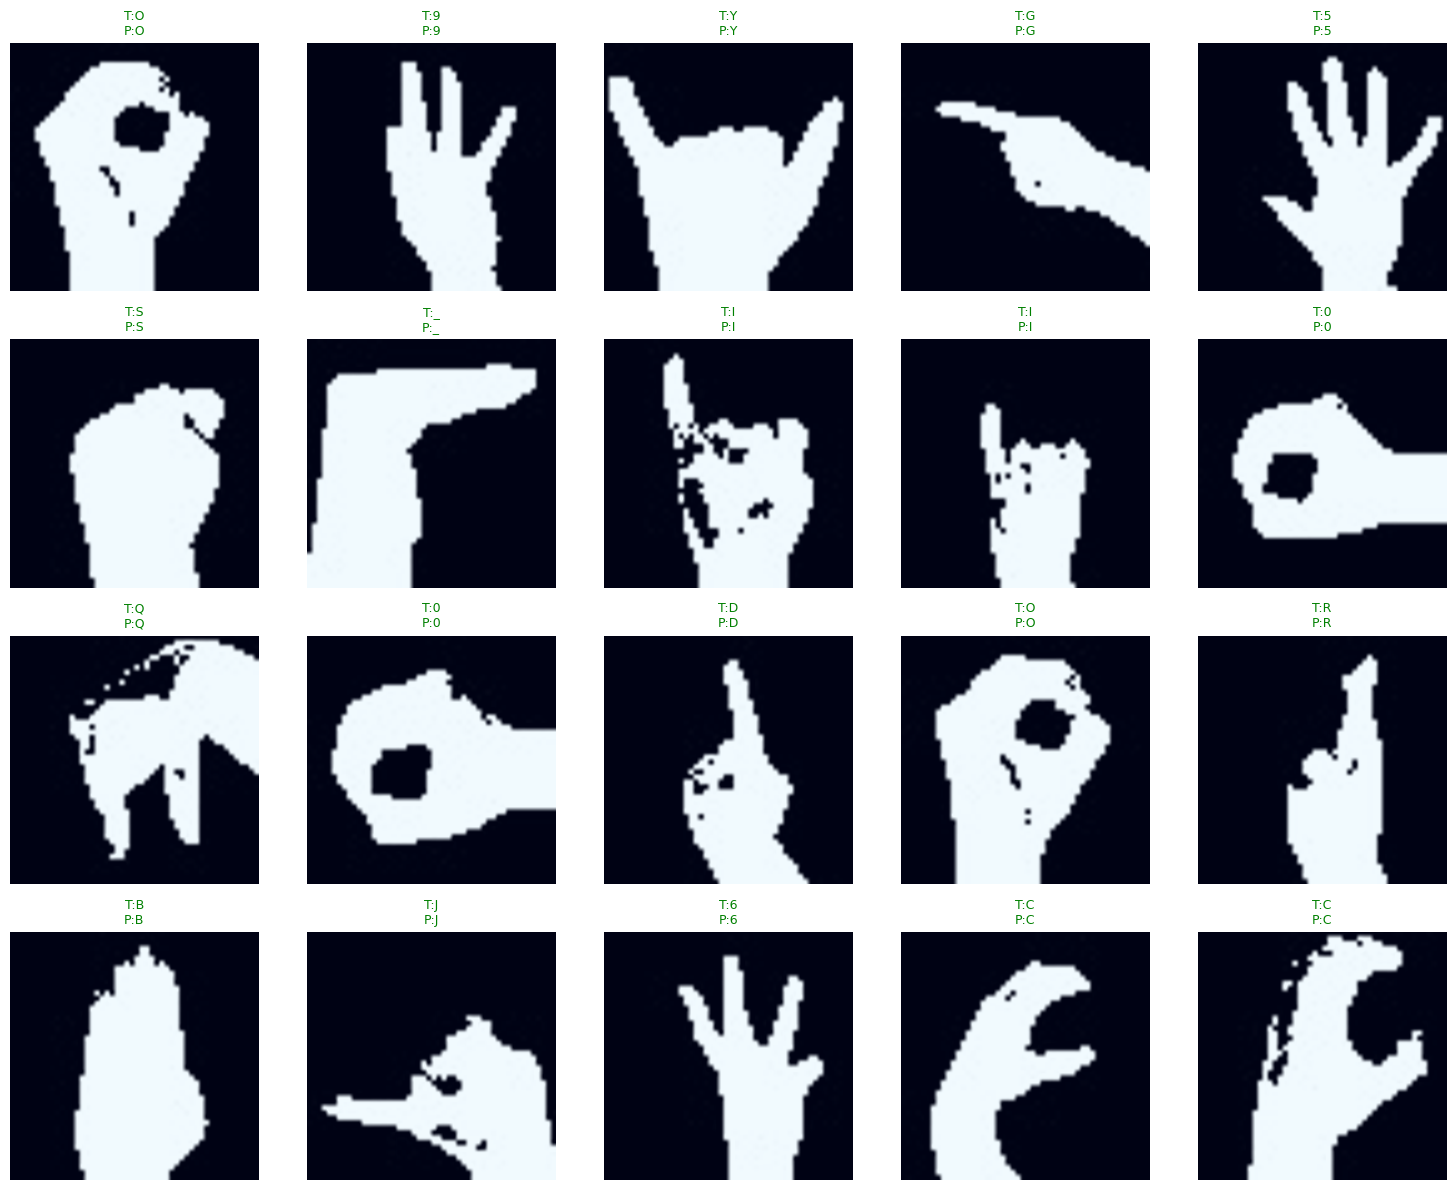

In [12]:
def show_examples_classifier(dataloader, num_batches=1):
    classifier.eval()
    shown = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                logits = classifier(images)
            preds = logits.argmax(dim=-1)

            images_np = images.cpu().permute(0, 2, 3, 1).numpy()
            labels_np = labels.cpu().numpy()
            preds_np  = preds.cpu().numpy()

            batch_size = images_np.shape[0]
            cols = 5
            rows = min(4, (batch_size + cols - 1) // cols)
            plt.figure(figsize=(3*cols, 3*rows))

            for i in range(min(batch_size, rows*cols)):
                plt.subplot(rows, cols, i+1)
                img = images_np[i]
                img = (img - img.min()) / (img.max() - img.min() + 1e-6)
                plt.imshow(img)

                true_cls = classes[labels_np[i]]
                pred_cls = classes[preds_np[i]]

                title = f"T:{true_cls}\nP:{pred_cls}"
                color = "green" if true_cls == pred_cls else "red"
                plt.title(title, color=color, fontsize=9)
                plt.axis("off")

            plt.tight_layout()
            plt.show()

            shown += 1
            if shown >= num_batches:
                break

print("\nShowing a few prediction examples from the TEST set (TRAINED CLASSIFIER)...")
show_examples_classifier(test_loader, num_batches=2)


In [13]:
save_path = "/kaggle/working/sign_classifier.pt"

if isinstance(classifier, nn.DataParallel):
    torch.save(classifier.module.state_dict(), save_path)
else:
    torch.save(classifier.state_dict(), save_path)

print("Saved PyTorch model:", save_path)


Saved PyTorch model: /kaggle/working/sign_classifier.pt
